In [1]:
import os
import pandas as pd
import numpy as np
from statsmodels.stats.inter_rater import fleiss_kappa

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    classification_report
)

import matplotlib.pyplot as plt

In [2]:
file_mapping = {'file1': 'MATAVE', 'file2': 'LDA'}

results_dir = "./results/"
labels_dir = "./labels/"

In [3]:
agreement_mapping = {}

for folder in os.listdir(results_dir):
    folder_path = os.path.join(results_dir, folder)

    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):

        key = file.replace('UnlabelledNotes.xlsx', '')

        df = pd.read_excel(os.path.join(folder_path, file))

        agreement_mapping.setdefault(key, []).append(df)

/Users/isabel/anaconda3/envs/localSyntheticData/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
/Users/isabel/anaconda3/envs/localSyntheticData/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
/Users/isabel/anaconda3/envs/localSyntheticData/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
/Users/isabel/anaconda3/envs/localSyntheticData/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


In [4]:
for file, raters in agreement_mapping.items():

    print("---------------------------------------------")
    print(f"----------- {file_mapping[file]} -----------")
    print("---------------------------------------------")

    rater_cols = [df['needs'] for df in raters]

    temp_dict = {
        f"rater_{i}": r for i, r in enumerate(rater_cols)
    }

    ratings = pd.DataFrame(temp_dict).dropna()

    categories = sorted(pd.unique(ratings.values.ravel()))

    fleiss_matrix = []

    for _, row in ratings.iterrows():
        counts = [(row == cat).sum() for cat in categories]
        fleiss_matrix.append(counts)

    fleiss_matrix = np.array(fleiss_matrix)

    n_raters = len(rater_cols)

    assert np.all(
        fleiss_matrix.sum(axis=1) == n_raters
    ), "Mismatch in number of raters per item"

    kappa = fleiss_kappa(fleiss_matrix)

    print(f"Fleiss' kappa ({file_mapping[file]}): {kappa}\n")

---------------------------------------------
----------- MATAVE -----------
---------------------------------------------
Fleiss' kappa (MATAVE): 0.6362414133563011

---------------------------------------------
----------- LDA -----------
---------------------------------------------
Fleiss' kappa (LDA): 0.6202962962962962



In [5]:
def get_rater_scores(model, human, title, file_name):

    print("Accuracy:", accuracy_score(human, model))
    print("Precision:", precision_score(human, model, pos_label='unmet'))
    print("Recall:", recall_score(human, model, pos_label='unmet'))
    print("F1 Score:", f1_score(human, model, pos_label='unmet'))
    print("Cohen's Kappa:", cohen_kappa_score(human, model))
    print()
    print(classification_report(human, model))

    cm = confusion_matrix(human, model, labels=['met', 'unmet'])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['met', 'unmet']
    )

    disp.plot()

    plt.xlabel('Model Labels')
    plt.ylabel('Human Labels')
    plt.title(title)

    os.makedirs("./graphs/", exist_ok=True)
    plt.savefig(f"./graphs/{file_name}.png")

    plt.show()

---------------------------------------------
----------- MATAVE -----------
---------------------------------------------
Accuracy: 0.7792792792792793
Precision: 0.872093023255814
Recall: 0.6637168141592921
F1 Score: 0.7537688442211056
Cohen's Kappa: 0.5603427370463181

              precision    recall  f1-score   support

         met       0.72      0.90      0.80       109
       unmet       0.87      0.66      0.75       113

    accuracy                           0.78       222
   macro avg       0.80      0.78      0.78       222
weighted avg       0.80      0.78      0.78       222



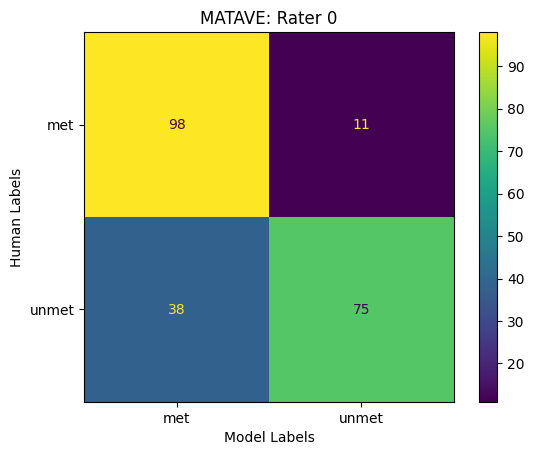

Accuracy: 0.8288288288288288
Precision: 0.8947368421052632
Recall: 0.7522123893805309
F1 Score: 0.8173076923076923
Cohen's Kappa: 0.658544483121509

              precision    recall  f1-score   support

         met       0.78      0.91      0.84       109
       unmet       0.89      0.75      0.82       113

    accuracy                           0.83       222
   macro avg       0.84      0.83      0.83       222
weighted avg       0.84      0.83      0.83       222



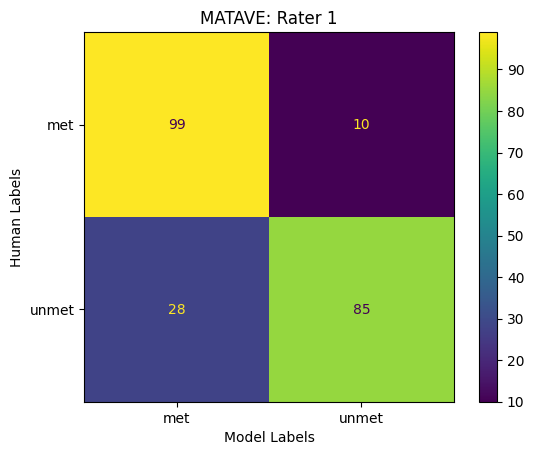

---------------------------------------------
----------- LDA -----------
---------------------------------------------
Accuracy: 0.8025751072961373
Precision: 0.7751937984496124
Recall: 0.8547008547008547
F1 Score: 0.8130081300813008
Cohen's Kappa: 0.604968303110718

              precision    recall  f1-score   support

         met       0.84      0.75      0.79       116
       unmet       0.78      0.85      0.81       117

    accuracy                           0.80       233
   macro avg       0.81      0.80      0.80       233
weighted avg       0.81      0.80      0.80       233



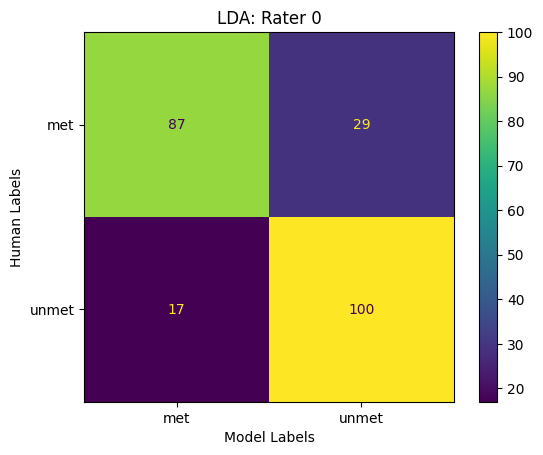

Accuracy: 0.9399141630901288
Precision: 0.9256198347107438
Recall: 0.9572649572649573
F1 Score: 0.9411764705882353
Cohen's Kappa: 0.8798084008843037

              precision    recall  f1-score   support

         met       0.96      0.92      0.94       116
       unmet       0.93      0.96      0.94       117

    accuracy                           0.94       233
   macro avg       0.94      0.94      0.94       233
weighted avg       0.94      0.94      0.94       233



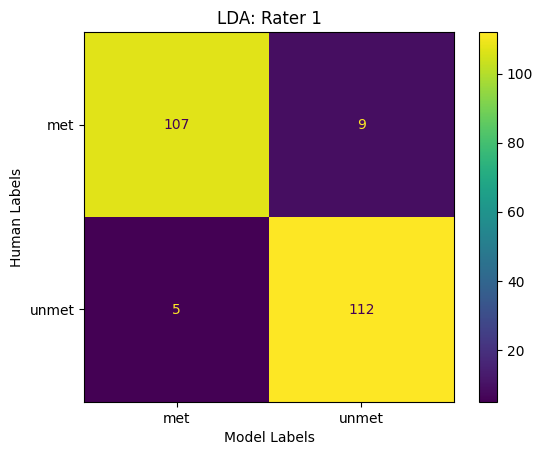

In [6]:
for file, raters in agreement_mapping.items():

    print("---------------------------------------------")
    print(f"----------- {file_mapping[file]} -----------")
    print("---------------------------------------------")

    gpt_raters = [df['needs'] for df in raters]

    human = pd.read_excel(
        f"{labels_dir}{file_mapping[file]}_labelled_notes.xlsx"
    )['needs']

    temp_dict = {
        f"rater_{i}": r for i, r in enumerate(gpt_raters)
    }

    temp_dict["real"] = human

    ratings = pd.DataFrame(temp_dict).dropna()

    model = ratings["rater_0"]
    human_clean = ratings["real"]

    get_rater_scores(
        model,
        human_clean,
        title=f"{file_mapping[file]}: Rater 0",
        file_name=f"{file_mapping[file]}_rater0"
    )

    model = ratings["rater_1"]
    human_clean = ratings["real"]

    get_rater_scores(
        model,
        human_clean,
        title=f"{file_mapping[file]}: Rater 1",
        file_name=f"{file_mapping[file]}_rater1"
    )